# Marker Curvature Heatmaps

This notebook loads curvature from the Project-B-style GNN dataset exported by `scripts_dev/build_GNN_dataset_patched.py`, reloads the full marker matrices from the source graphs for dataset `20250929`, computes marker-wise Gaussian-curvature summaries after harmonization and exclusivity, plots one heatmap per requested timepoint group, and exports CSV tables with the plotting data.

The builder exports all timepoints into one folder. Paste that folder path in the configuration cell below. The notebook extracts timepoint information from each organoid's `_aux.json` sidecar when available, then from `manifest.csv`, and finally from the `organoid_<label_uid>.npz` filename.


In [1]:
from __future__ import annotations

import json
import re
from functools import lru_cache
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from organograph.graph.access import graph_get
from organograph.graph.io import load_cell_graph


## Configuration

Paste one or more export folders generated by `scripts_dev/build_GNN_dataset_patched.py`. Each folder is expected to contain files like:

```text
organoid_<label_uid>.npz
organoid_<label_uid>_aux.json
manifest.csv
```

The `_aux.json` sidecar or `manifest.csv` should contain the source `graph_path`. If that path is stale or absent, the notebook matches `label_uid` and timepoint against `SOURCE_DATA_ROOT / TARGET_DATASET / graphs_preprocessed`.


In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"notebooks", "notebooks_dev", "legacy"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOK_NAME = "curvature_marker_heatmaps"
EXPORT_DIR = PROJECT_ROOT / "exports" / NOTEBOOK_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Paste the folder(s) generated by scripts_dev/build_GNN_dataset_patched.py here.
GNN_EXPORT_DIRS = [
    Path("/home/fmoller/Projects/LearningOrganoids/GraphNN/training_data/after_cleanup"),
]

# Restrict analysis to this dataset. Full marker matrices are reloaded from
# its source graphs because multi-dataset NPZ exports contain only markers
# shared by every exported dataset.
TARGET_DATASET = "20250929"
SOURCE_DATA_ROOT = (PROJECT_ROOT / ".." / "NicoleData").resolve()
SOURCE_GRAPH_SUBDIR = "graphs_preprocessed"
NONE_MARKER_NAME = "none"

PROLIFERATION_MARKER_ALIASES = ["Cyclin A", "Cyclin D", "KI67"]
EXCLUSIVITY_RULES = {
    "LGR5": ["Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
    "Chroma": ["Mucin 2", "Glucagon", "Serotonin", "Lysozyme"],
    "Mucin 2": ["Chroma", "Glucagon", "Serotonin", "Lysozyme"],
    "AldoB": ["Chroma", "Mucin 2", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
    "Glucagon": ["Serotonin"],
    "Agr2": ["Chroma", "Mucin 2", "Glucagon", "Serotonin", "Lysozyme"],
    "Serotonin": [],
    "Lysozyme": ["Chroma", "Glucagon", "Serotonin"],
    "KI67": ["LGR5", "Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
}

# Timepoint groups to compare. The day4_day4p5 group includes day4p5-more by
# default because build_GNN_dataset_patched.py exports that folder together with day4/day4p5.
TIMEPOINT_GROUPS = {
    "day3p5": ["day3p5"],
    "day4_day4p5": ["day4", "day4p5", "day4p5-more"],
}

Y_FIELD = "y"  # target array exported by build_GNN_dataset_patched.py
Y_COLUMN = 0  # if y is 2D, use column 0 as Gaussian curvature

# Aggregation is equal-organoid weighted: marker stats are computed inside each
# organoid first, then averaged across organoids in the timepoint group.
HEATMAP_COLOR_MODE = "column_zscore"  # "column_zscore" or "raw"
HEATMAP_CMAP = "coolwarm"


## Loading Helpers


In [3]:
def as_path(value: str | Path) -> Path:
    return Path(value).expanduser().resolve()


def organoid_stem_from_npz(path: Path) -> str:
    return path.stem


def label_uid_from_stem(stem: str) -> str:
    return stem.removeprefix("organoid_")


def aux_path_for_npz(path: Path) -> Path:
    return path.with_name(f"{path.stem}_aux.json")


def discover_organoid_npz_files(export_dirs: list[str | Path]) -> list[Path]:
    files: list[Path] = []
    seen: set[Path] = set()
    for value in export_dirs:
        folder = as_path(value)
        if folder.is_file() and folder.name.startswith("organoid_") and folder.suffix == ".npz":
            candidates = [folder]
        elif folder.is_dir():
            candidates = sorted(folder.glob("organoid_*.npz"))
        else:
            print(f"[warn] export path does not exist: {folder}")
            continue

        for path in candidates:
            # Only data npz files; JSON sidecars are separate and do not match this suffix.
            path = path.resolve()
            if path not in seen:
                seen.add(path)
                files.append(path)
    return files


def read_json_if_exists(path: Path) -> dict[str, Any] | list[Any] | None:
    if not path.exists():
        return None
    with path.open("r") as handle:
        return json.load(handle)


def load_manifest_tables(export_dirs: list[str | Path]) -> dict[Path, pd.DataFrame]:
    tables = {}
    for value in export_dirs:
        folder = as_path(value)
        manifest_path = folder / "manifest.csv" if folder.is_dir() else folder.parent / "manifest.csv"
        if manifest_path.exists():
            try:
                tables[manifest_path.parent.resolve()] = pd.read_csv(manifest_path)
            except Exception as exc:
                print(f"[warn] could not read manifest {manifest_path}: {exc}")
    return tables


def manifest_row_for_npz(path: Path, manifests: dict[Path, pd.DataFrame]) -> dict[str, Any]:
    folder = path.parent.resolve()
    manifest = manifests.get(folder)
    if manifest is None or manifest.empty:
        return {}

    label_uid = label_uid_from_stem(path.stem)
    for col in ["out_path", "label_uid"]:
        if col not in manifest.columns:
            continue
        if col == "out_path":
            mask = manifest[col].astype(str).map(lambda p: Path(p).name == path.name)
        else:
            mask = manifest[col].astype(str).eq(label_uid)
        if mask.any():
            row = manifest.loc[mask].iloc[0].to_dict()
            return {k: (None if pd.isna(v) else v) for k, v in row.items()}
    return {}


def timepoint_from_label_uid(label_uid: str) -> str | None:
    match = re.match(r"(day\d+(?:p\d+)?(?:-more)?)_", str(label_uid))
    if match:
        return match.group(1)
    return None


def dataset_from_metadata_paths(*values: Any) -> str | None:
    for value in values:
        if value is None:
            continue
        match = re.search(r"(?:^|[/\\])(20\d{6})(?:[/\\]|$)", str(value))
        if match:
            return match.group(1)
    return None


def graph_path_from_label_uid(label_uid: str, timepoint: str | None, dataset: str) -> Path | None:
    if timepoint is None:
        return None
    candidate = SOURCE_DATA_ROOT / dataset / SOURCE_GRAPH_SUBDIR / str(timepoint) / f"{label_uid}.gpickle"
    return candidate.resolve() if candidate.exists() else None


def metadata_for_npz(path: Path, manifests: dict[Path, pd.DataFrame]) -> dict[str, Any]:
    aux = read_json_if_exists(aux_path_for_npz(path))
    aux = aux if isinstance(aux, dict) else {}
    manifest_row = manifest_row_for_npz(path, manifests)

    label_uid = (
        aux.get("label_uid")
        or manifest_row.get("label_uid")
        or label_uid_from_stem(path.stem)
    )
    timepoint = (
        aux.get("timepoint")
        or manifest_row.get("timepoint")
        or timepoint_from_label_uid(str(label_uid))
    )
    dataset = (
        aux.get("dataset")
        or manifest_row.get("dataset")
        or dataset_from_metadata_paths(
            aux.get("graph_path"),
            manifest_row.get("graph_path"),
            aux.get("mesh_path"),
            manifest_row.get("mesh_path"),
        )
    )
    if dataset is None and graph_path_from_label_uid(str(label_uid), timepoint, TARGET_DATASET):
        dataset = TARGET_DATASET

    return {
        **manifest_row,
        **aux,
        "label_uid": str(label_uid),
        "timepoint": None if timepoint is None else str(timepoint),
        "dataset": None if dataset is None else str(dataset),
        "npz_path": str(path),
    }


def group_for_timepoint(timepoint: str | None) -> str | None:
    if timepoint is None:
        return None
    tp = str(timepoint)
    for group_name, timepoints in TIMEPOINT_GROUPS.items():
        if tp in set(map(str, timepoints)):
            return group_name
    return None


## Curvature And Marker Statistics

For each organoid, the notebook harmonizes Cyclin A, Cyclin D, and KI67 into KI67, applies the configured marker-exclusivity rules, and labels cells with no remaining positive marker as `none`. It then computes marker-positive cell curvature summaries relative to that organoid's own Gaussian-curvature mean. The timepoint-group summary averages these organoid-level values across organoids, so each organoid has equal weight.


In [4]:
def infer_graph_marker_names(graph) -> list[str]:
    for key in ["marker_names", "markers", "marker_cols"]:
        names = graph.graph.get(key)
        if names is not None:
            return [str(name) for name in names]
    raise KeyError("Source graph does not contain marker names in its metadata")


@lru_cache(maxsize=None)
def load_source_graph_cached(graph_path: str):
    return load_cell_graph(graph_path)


def resolve_source_graph_path(path: Path, metadata: dict[str, Any]) -> Path:
    stored = metadata.get("graph_path")
    if stored:
        stored_path = Path(str(stored)).expanduser()
        if stored_path.exists():
            return stored_path.resolve()

    fallback = graph_path_from_label_uid(
        str(metadata.get("label_uid")),
        metadata.get("timepoint"),
        TARGET_DATASET,
    )
    if fallback is not None:
        return fallback

    label_uid = str(metadata.get("label_uid"))
    matches = list(
        (SOURCE_DATA_ROOT / TARGET_DATASET / SOURCE_GRAPH_SUBDIR).glob(f"*/{label_uid}.gpickle")
    )
    if len(matches) == 1:
        return matches[0].resolve()
    raise FileNotFoundError(f"Could not resolve a unique source graph for {path}")


def align_graph_markers_to_export(
    markers: np.ndarray,
    graph,
    exported_arrays: dict[str, np.ndarray],
    n_exported: int,
) -> np.ndarray:
    markers = np.asarray(markers)
    if markers.shape[0] == n_exported:
        return markers

    keep_mask = exported_arrays.get("keep_mask")
    if keep_mask is not None:
        keep_mask = np.asarray(keep_mask, dtype=bool).reshape(-1)
        if keep_mask.size == markers.shape[0] and int(keep_mask.sum()) == n_exported:
            return markers[keep_mask]

    new_to_old = exported_arrays.get("new_to_old_index")
    if new_to_old is not None:
        new_to_old = np.asarray(new_to_old, dtype=np.int64).reshape(-1)
        if new_to_old.size == n_exported and np.all((new_to_old >= 0) & (new_to_old < markers.shape[0])):
            return markers[new_to_old]

    kept_node_ids = exported_arrays.get("kept_node_ids")
    if kept_node_ids is not None:
        node_to_position = {int(node): pos for pos, node in enumerate(sorted(graph.nodes()))}
        try:
            positions = np.asarray(
                [node_to_position[int(node)] for node in np.asarray(kept_node_ids).reshape(-1)],
                dtype=np.int64,
            )
        except KeyError:
            positions = np.array([], dtype=np.int64)
        if positions.size == n_exported:
            return markers[positions]

    raise ValueError(
        f"Could not align {markers.shape[0]} source-graph marker rows to {n_exported} exported cells"
    )


def harmonize_proliferation_markers(
    markers: np.ndarray, marker_names: list[str]
) -> tuple[np.ndarray, list[str]]:
    markers = np.asarray(markers, dtype=bool)
    alias_keys = {name.strip().casefold() for name in PROLIFERATION_MARKER_ALIASES}
    source_indices = [
        i for i, name in enumerate(marker_names)
        if str(name).strip().casefold() in alias_keys
    ]
    if not source_indices:
        raise KeyError(f"None of the proliferation markers were found: {PROLIFERATION_MARKER_ALIASES}")

    keep_indices = [i for i in range(len(marker_names)) if i not in source_indices]
    ki67 = np.any(markers[:, source_indices], axis=1)
    harmonized = np.column_stack([markers[:, keep_indices], ki67])
    harmonized_names = [str(marker_names[i]) for i in keep_indices] + ["KI67"]
    return harmonized.astype(bool), harmonized_names


def apply_marker_exclusivity(
    markers: np.ndarray, marker_names: list[str]
) -> tuple[np.ndarray, list[str]]:
    markers_before_exclusion = np.asarray(markers, dtype=bool).copy()
    markers_after_exclusion = markers_before_exclusion.copy()
    name_to_index = {str(name).strip().casefold(): i for i, name in enumerate(marker_names)}

    required = {str(name).strip().casefold() for name in EXCLUSIVITY_RULES}
    required.update(
        str(name).strip().casefold()
        for excluded in EXCLUSIVITY_RULES.values()
        for name in excluded
    )
    missing = sorted(required.difference(name_to_index))
    if missing:
        raise KeyError(f"Markers required by EXCLUSIVITY_RULES are missing: {missing}")

    for marker, excluded_markers in EXCLUSIVITY_RULES.items():
        marker_idx = name_to_index[marker.strip().casefold()]
        excluded_idx = [name_to_index[name.strip().casefold()] for name in excluded_markers]
        conflicts = (
            np.any(markers_before_exclusion[:, excluded_idx], axis=1)
            if excluded_idx
            else np.zeros(markers_before_exclusion.shape[0], dtype=bool)
        )
        markers_after_exclusion[:, marker_idx] = (
            markers_before_exclusion[:, marker_idx] & ~conflicts
        )

    none_positive = ~np.any(markers_after_exclusion, axis=1)
    markers_after_exclusion = np.column_stack([markers_after_exclusion, none_positive])
    return markers_after_exclusion.astype(bool), list(marker_names) + [NONE_MARKER_NAME]


def load_organoid_arrays(
    path: Path, metadata: dict[str, Any]
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    with np.load(path, allow_pickle=True) as data:
        if Y_FIELD not in data:
            raise KeyError(f"{path} must contain array {Y_FIELD!r}")
        exported_arrays = {
            key: np.asarray(data[key])
            for key in ["keep_mask", "new_to_old_index", "kept_node_ids"]
            if key in data
        }
        y_raw = np.asarray(data[Y_FIELD], dtype=float)
    if y_raw.ndim == 1:
        y = y_raw.reshape(-1)
    elif y_raw.ndim == 2:
        if Y_COLUMN < 0 or Y_COLUMN >= y_raw.shape[1]:
            raise IndexError(
                f"{path}: Y_COLUMN={Y_COLUMN} is out of range for y with shape {y_raw.shape}"
            )
        y = y_raw[:, int(Y_COLUMN)].reshape(-1)
    else:
        raise ValueError(f"{path}: y must be 1D or 2D, got shape {y_raw.shape}")

    graph_path = resolve_source_graph_path(path, metadata)
    graph = load_source_graph_cached(str(graph_path))
    marker_names = infer_graph_marker_names(graph)
    markers = np.asarray(graph_get(graph, "markers_bin")) > 0.5
    markers = align_graph_markers_to_export(
        markers, graph, exported_arrays, n_exported=y.shape[0]
    )
    markers, marker_names = harmonize_proliferation_markers(markers, marker_names)
    markers, marker_names = apply_marker_exclusivity(markers, marker_names)

    if markers.shape[0] != y.shape[0]:
        raise ValueError(f"{path}: marker rows {markers.shape[0]} != curvature values {y.shape[0]}")
    return markers, y, marker_names


def organoid_marker_curvature_rows(path: Path, metadata: dict[str, Any], group_name: str) -> list[dict[str, Any]]:
    markers, curvature, marker_names = load_organoid_arrays(path, metadata)
    finite = np.isfinite(curvature)

    organoid_mean = float(np.nanmean(curvature[finite])) if np.any(finite) else np.nan
    organoid_std = float(np.nanstd(curvature[finite], ddof=0)) if np.any(finite) else np.nan
    denom = organoid_mean if np.isfinite(organoid_mean) and organoid_mean != 0 else np.nan

    rows: list[dict[str, Any]] = []
    for marker_idx, marker in enumerate(marker_names):
        positive = markers[:, marker_idx] & finite
        values = curvature[positive]
        n_positive = int(values.size)
        if n_positive:
            marker_mean = float(np.nanmean(values))
            marker_std = float(np.nanstd(values, ddof=0))
            mean_delta = marker_mean - organoid_mean if np.isfinite(organoid_mean) else np.nan
            std_over_organoid_mean = marker_std / denom if np.isfinite(denom) else np.nan
        else:
            marker_mean = np.nan
            marker_std = np.nan
            mean_delta = np.nan
            std_over_organoid_mean = np.nan

        rows.append({
            "timepoint_group": group_name,
            "dataset": metadata.get("dataset"),
            "timepoint": metadata.get("timepoint"),
            "label_uid": metadata.get("label_uid"),
            "npz_path": str(path),
            "marker": marker,
            "n_cells_organoid": int(curvature.size),
            "n_finite_curvature_cells": int(np.sum(finite)),
            "n_marker_positive_cells": n_positive,
            "frac_marker_positive_cells": float(n_positive / np.sum(finite)) if np.sum(finite) else np.nan,
            "organoid_mean_gaussian_curvature": organoid_mean,
            "organoid_std_gaussian_curvature": organoid_std,
            "marker_mean_gaussian_curvature": marker_mean,
            "marker_std_gaussian_curvature": marker_std,
            "marker_mean_minus_organoid_mean": mean_delta,
            "marker_std_divided_by_organoid_mean": std_over_organoid_mean,
        })
    return rows


def load_all_marker_curvature_rows() -> pd.DataFrame:
    manifests = load_manifest_tables(GNN_EXPORT_DIRS)
    npz_files = discover_organoid_npz_files(GNN_EXPORT_DIRS)
    print(f"Found {len(npz_files)} organoid npz files")

    rows: list[dict[str, Any]] = []
    skipped = []
    skipped_datasets: dict[str, int] = {}
    for path in npz_files:
        metadata = metadata_for_npz(path, manifests)
        dataset = str(metadata.get("dataset"))
        if dataset != TARGET_DATASET:
            skipped_datasets[dataset] = skipped_datasets.get(dataset, 0) + 1
            continue
        group_name = group_for_timepoint(metadata.get("timepoint"))
        if group_name is None:
            skipped.append((path, metadata.get("timepoint")))
            continue
        try:
            rows.extend(organoid_marker_curvature_rows(path, metadata, group_name))
        except Exception as exc:
            print(f"[warn] skipping {path}: {exc}")

    if skipped:
        skipped_tps = sorted({str(tp) for _, tp in skipped})
        print(f"Skipped {len(skipped)} files outside TIMEPOINT_GROUPS. Timepoints: {skipped_tps}")
    if skipped_datasets:
        print(f"Skipped files outside TARGET_DATASET={TARGET_DATASET}: {skipped_datasets}")
    return pd.DataFrame(rows)


per_organoid_df = load_all_marker_curvature_rows()
if per_organoid_df.empty:
    raise FileNotFoundError(
        "No organoid data were loaded. Paste the build_GNN_dataset_patched.py output folder "
        "into GNN_EXPORT_DIRS and confirm TIMEPOINT_GROUPS matches the exported timepoint labels."
    )

print("per-organoid rows:", per_organoid_df.shape)
display(per_organoid_df.head())


Found 1500 organoid npz files
Skipped files outside TARGET_DATASET=20250929: {'20251201': 278}
per-organoid rows: (12220, 16)


,timepoint_group,dataset,timepoint,label_uid,npz_path,marker,n_cells_organoid,n_finite_curvature_cells,n_marker_positive_cells,frac_marker_positive_cells,organoid_mean_gaussian_curvature,organoid_std_gaussian_curvature,marker_mean_gaussian_curvature,marker_std_gaussian_curvature,marker_mean_minus_organoid_mean,marker_std_divided_by_organoid_mean
0,day3p5,20250929,day3p5,day3p5_A01_1,/home/fmoller/Projects/LearningOrganoids/Graph...,LGR5,165,165,1,0.006061,0.096261,0.031817,0.073866,0.0,-0.022395,0.0
1,day3p5,20250929,day3p5,day3p5_A01_1,/home/fmoller/Projects/LearningOrganoids/Graph...,Chroma,165,165,0,0.000000,0.096261,0.031817,NaN,NaN,NaN,NaN
2,day3p5,20250929,day3p5,day3p5_A01_1,/home/fmoller/Projects/LearningOrganoids/Graph...,Mucin 2,165,165,1,0.006061,0.096261,0.031817,0.070931,0.0,-0.025330,0.0
3,day3p5,20250929,day3p5,day3p5_A01_1,/home/fmoller/Projects/LearningOrganoids/Graph...,AldoB,165,165,0,0.000000,0.096261,0.031817,NaN,NaN,NaN,NaN
4,day3p5,20250929,day3p5,day3p5_A01_1,/home/fmoller/Projects/LearningOrganoids/Graph...,Glucagon,165,165,0,0.000000,0.096261,0.031817,NaN,NaN,NaN,NaN


In [5]:
METRIC_COLUMNS = [
    "marker_mean_gaussian_curvature",
    "marker_std_gaussian_curvature",
    "marker_mean_minus_organoid_mean",
    "marker_std_divided_by_organoid_mean",
]

METRIC_LABELS = {
    "marker_mean_gaussian_curvature": "mean K",
    "marker_std_gaussian_curvature": "std K",
    "marker_mean_minus_organoid_mean": "mean K - organoid mean K",
    "marker_std_divided_by_organoid_mean": "std K / organoid mean K",
}


def summarize_marker_curvature(per_organoid: pd.DataFrame) -> pd.DataFrame:
    agg_spec = {
        "n_marker_positive_cells": "sum",
        "frac_marker_positive_cells": "mean",
        "label_uid": "nunique",
    }
    for col in METRIC_COLUMNS:
        agg_spec[col] = "mean"

    out = (
        per_organoid
        .groupby(["timepoint_group", "marker"], dropna=False)
        .agg(agg_spec)
        .reset_index()
        .rename(columns={
            "label_uid": "n_organoids",
            "n_marker_positive_cells": "total_marker_positive_cells",
            "frac_marker_positive_cells": "mean_marker_positive_fraction",
        })
    )

    present = (
        per_organoid[per_organoid["n_marker_positive_cells"] > 0]
        .groupby(["timepoint_group", "marker"], dropna=False)["label_uid"]
        .nunique()
        .rename("n_organoids_with_marker")
        .reset_index()
    )
    out = out.merge(present, on=["timepoint_group", "marker"], how="left")
    out["n_organoids_with_marker"] = out["n_organoids_with_marker"].fillna(0).astype(int)
    return out


summary_df = summarize_marker_curvature(per_organoid_df)
print("summary rows:", summary_df.shape)
display(summary_df.head())


summary rows: (20, 10)


,timepoint_group,marker,total_marker_positive_cells,mean_marker_positive_fraction,n_organoids,marker_mean_gaussian_curvature,marker_std_gaussian_curvature,marker_mean_minus_organoid_mean,marker_std_divided_by_organoid_mean,n_organoids_with_marker
0,day3p5,Agr2,1478,0.026245,290,0.096095,0.033914,0.038254,0.509691,217
1,day3p5,AldoB,8219,0.194891,290,0.089042,0.017946,-0.001148,0.237619,175
2,day3p5,Chroma,134,0.002349,290,0.135252,0.021225,0.110716,0.203175,86
3,day3p5,Glucagon,19,0.000356,290,0.110642,0.002076,0.041013,0.031799,14
4,day3p5,KI67,14740,0.258850,290,0.082034,0.050499,0.017490,0.589615,265


## Heatmaps

Each heatmap has markers as rows and metrics as columns. By default the colors are column-wise z-scores because the four metrics have different units/scales; the cell annotations show the raw plotted values. Set `HEATMAP_COLOR_MODE = "raw"` in the configuration cell to color by raw values instead.


Saved figure: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/curvature_marker_heatmaps/marker_curvature_heatmap_day3p5.pdf


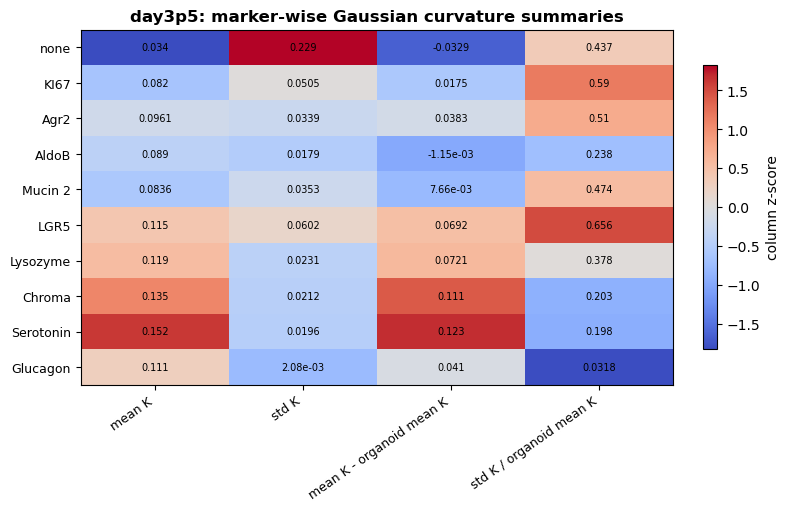

Saved figure: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/curvature_marker_heatmaps/marker_curvature_heatmap_day4_day4p5.pdf


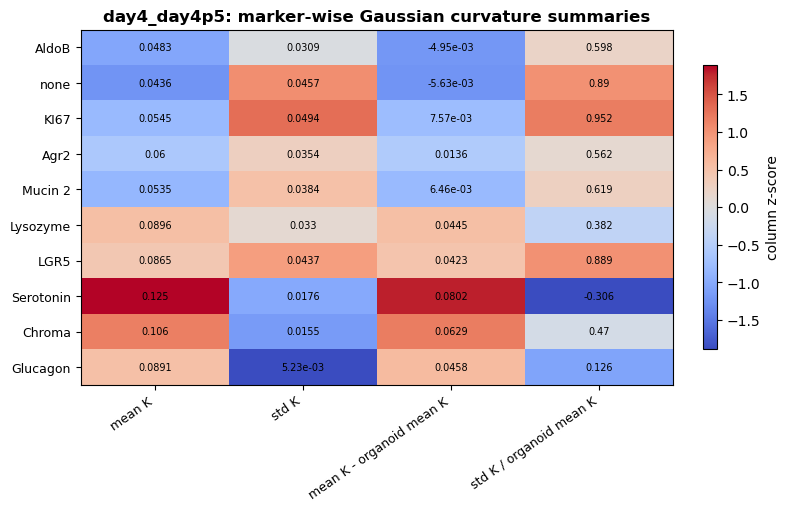

In [6]:
def marker_order_for_group(summary: pd.DataFrame, group_name: str) -> list[str]:
    sub = summary[summary["timepoint_group"] == group_name].copy()
    if sub.empty:
        return []
    sub = sub.sort_values(
        ["n_organoids_with_marker", "total_marker_positive_cells", "marker"],
        ascending=[False, False, True],
    )
    return sub["marker"].tolist()


def heatmap_matrix(summary: pd.DataFrame, group_name: str) -> pd.DataFrame:
    markers = marker_order_for_group(summary, group_name)
    sub = summary[summary["timepoint_group"] == group_name].set_index("marker")
    matrix = sub.reindex(markers)[METRIC_COLUMNS]
    matrix = matrix.rename(columns=METRIC_LABELS)
    return matrix


def color_matrix(values: pd.DataFrame) -> np.ndarray:
    arr = values.to_numpy(dtype=float)
    if HEATMAP_COLOR_MODE == "raw":
        return arr
    if HEATMAP_COLOR_MODE != "column_zscore":
        raise ValueError('HEATMAP_COLOR_MODE must be "column_zscore" or "raw"')
    out = np.full_like(arr, np.nan, dtype=float)
    for j in range(arr.shape[1]):
        col = arr[:, j]
        finite = np.isfinite(col)
        if not np.any(finite):
            continue
        mu = np.nanmean(col)
        sd = np.nanstd(col, ddof=0)
        if not np.isfinite(sd) or sd == 0:
            out[finite, j] = 0.0
        else:
            out[finite, j] = (col[finite] - mu) / sd
    return out


def format_value(value: float) -> str:
    if not np.isfinite(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 100 or (abs_value > 0 and abs_value < 0.01):
        return f"{value:.2e}"
    return f"{value:.3g}"


def plot_group_heatmap(summary: pd.DataFrame, group_name: str):
    values = heatmap_matrix(summary, group_name)
    if values.empty:
        raise ValueError(f"No summary rows for group {group_name!r}")

    colors = color_matrix(values)
    finite_colors = colors[np.isfinite(colors)]
    if finite_colors.size:
        vmax = float(np.nanpercentile(np.abs(finite_colors), 95))
        vmax = max(vmax, 1e-12)
    else:
        vmax = 1.0

    fig_height = max(3.0, 0.36 * len(values.index) + 1.4)
    fig_width = 7.8
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    im = ax.imshow(colors, aspect="auto", cmap=HEATMAP_CMAP, vmin=-vmax, vmax=vmax)

    ax.set_xticks(np.arange(values.shape[1]))
    ax.set_xticklabels(values.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(values.shape[0]))
    ax.set_yticklabels(values.index)
    ax.set_title(f"{group_name}: marker-wise Gaussian curvature summaries", fontweight="bold")

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            text = format_value(values.iloc[i, j])
            if text:
                ax.text(j, i, text, ha="center", va="center", fontsize=7, color="black")

    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("column z-score" if HEATMAP_COLOR_MODE == "column_zscore" else "raw value")
    ax.tick_params(axis="both", labelsize=9)
    return fig, ax, values


heatmap_tables = {}
for group_name in TIMEPOINT_GROUPS:
    if group_name not in set(summary_df["timepoint_group"]):
        print(f"[warn] no loaded data for group {group_name}")
        continue
    fig, ax, values = plot_group_heatmap(summary_df, group_name)
    heatmap_tables[group_name] = values
    fig_path = EXPORT_DIR / f"marker_curvature_heatmap_{group_name}.pdf"
    fig.savefig(fig_path, bbox_inches="tight")
    print(f"Saved figure: {fig_path}")
    plt.show()


## Export Plot Data


In [7]:
per_organoid_csv = EXPORT_DIR / "marker_curvature_stats_per_organoid.csv"
summary_csv = EXPORT_DIR / "marker_curvature_stats_summary.csv"
per_organoid_df.to_csv(per_organoid_csv, index=False)
summary_df.to_csv(summary_csv, index=False)
print(f"Saved CSV: {per_organoid_csv}")
print(f"Saved CSV: {summary_csv}")

for group_name, table in heatmap_tables.items():
    long_table = table.reset_index().melt(
        id_vars="marker",
        var_name="metric",
        value_name="value",
    )
    heatmap_csv = EXPORT_DIR / f"marker_curvature_heatmap_{group_name}_plot_data.csv"
    long_table.to_csv(heatmap_csv, index=False)
    print(f"Saved CSV: {heatmap_csv}")


Saved CSV: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/curvature_marker_heatmaps/marker_curvature_stats_per_organoid.csv
Saved CSV: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/curvature_marker_heatmaps/marker_curvature_stats_summary.csv
Saved CSV: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/curvature_marker_heatmaps/marker_curvature_heatmap_day3p5_plot_data.csv
Saved CSV: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/curvature_marker_heatmaps/marker_curvature_heatmap_day4_day4p5_plot_data.csv
